# Train Multimodal Deep Learning Models

### Purpose

- Implements concatenation MLP and attention fusion architectures for multimodal survival prediction.
- Goal is to demonstrate fusion architecture patterns and show empirically why clinical baselines are hard to beat at this sample size, not to show deep learning wins.

### Objectives
- Define shared MLP encoder architectures for RNA and clinical modalities.
- Train a concatenation fusion model (no attention) as the deep learning baseline.
- Train an attention fusion model that learns per-patient modality weights.
- A quick validation comparison against prior baselines, full analysis in 09_analysis_and_model_selection.ipynb
- Prototype modeling and evaluation steps before implementation in the pipeline.

### Workflow

1. Load and inspect assembled datasets
   - Load preprocessed feature matrices and outcome labels produced by the data assembly step.
   - Confirm expected shapes and verify sample alignment between features and outcome labels.

**Subsequent exploratory steps use the training and validation data only.**

2. Define encoder architecture
   - Define RNA encoder: 25k → 128 → 64 (MLP with ReLU and dropout).
   - Define clinical encoder: 98 → 64 → 64 (shallower MLP with ReLU and dropout).
   - Encoders are shared across both fusion models.

3. Train concatenation fusion model
   - Concatenate RNA and clinical embeddings.
   - Pass through a classification head (MLP → sigmoid).
   - Train end-to-end on the binary survival label using BCE loss.

4. Train attention fusion model
   - Pass RNA and clinical embeddings through a learned attention network.
   - Compute per-patient modality weights; take weighted combination of embeddings.
   - Pass fused embedding through classification head.
   - Train end-to-end on the binary survival label using BCE loss.

5. Compare all models
   - Generate validation predictions for both deep learning models.
   - Assemble full model comparison table: Clinical LR, RNA LR, XGBoost, Concat MLP, Attention fusion.
   - Evaluate risk-tier separation for deep learning models.

**Now evaluate on test data.**

6. Evaluate final models on the test set
   - Generate test predictions for both deep learning models.
   - Compute final evaluation metrics and ROC curves.

7. Validate modeling outputs
   - Confirm prediction counts match split sizes.
   - Verify sample alignment across datasets.
   - Verify no data leakage between splits.

8. Test multimodal module

## 1. Load and inspect assembled datasets
   - Load preprocessed feature matrices and outcome labels produced by the data assembly step.
   - Confirm expected shapes and verify sample alignment between features and outcome labels.

In [8]:
# imports
from pathlib import Path
import pickle
import subprocess
import sys
import json
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import display
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

In [9]:
# load assembled feature matrices and targets for each split

def load_datasets(
    assembled_dir: Path,
) -> tuple[
    pd.DataFrame, pd.DataFrame, pd.DataFrame,
    pd.DataFrame, pd.DataFrame, pd.DataFrame,
    pd.Series, pd.Series, pd.Series,
]:
    """Load assembled train/val/test feature matrices and targets from parquet files.

    Args:
        assembled_dir: Path to the assembled dataset directory.

    Returns:
        X_clin_train_df, X_clin_val_df, X_clin_test_df: clinical feature matrices.
        X_rna_train_df, X_rna_val_df, X_rna_test_df: RNA feature matrices.
        y_train, y_val, y_test: binary outcome vectors.
    """
    assembled_dir = Path(assembled_dir)

    X_clin_train_df = pd.read_parquet(assembled_dir / "train/X_clinical.parquet")
    X_clin_val_df   = pd.read_parquet(assembled_dir / "val/X_clinical.parquet")
    X_clin_test_df  = pd.read_parquet(assembled_dir / "test/X_clinical.parquet")

    X_rna_train_df  = pd.read_parquet(assembled_dir / "train/X_rna.parquet")
    X_rna_val_df    = pd.read_parquet(assembled_dir / "val/X_rna.parquet")
    X_rna_test_df   = pd.read_parquet(assembled_dir / "test/X_rna.parquet")

    y_train = pd.read_parquet(assembled_dir / "train/y.parquet")["y"]
    y_val   = pd.read_parquet(assembled_dir / "val/y.parquet")["y"]
    y_test  = pd.read_parquet(assembled_dir / "test/y.parquet")["y"]

    for split, X_clin, X_rna, y in [
        ("train", X_clin_train_df, X_rna_train_df, y_train),
        ("val",   X_clin_val_df,   X_rna_val_df,   y_val),
        ("test",  X_clin_test_df,  X_rna_test_df,  y_test),
    ]:
        assert X_clin.index.equals(X_rna.index), f"{split}: clinical/RNA index mismatch"
        assert X_clin.index.equals(y.index),     f"{split}: clinical/y index mismatch"
        print(f"{split}: n={len(y)}, n_events={y.sum()}, clin={X_clin.shape[1]} features, rna={X_rna.shape[1]} features")

    return (
        X_clin_train_df, X_clin_val_df, X_clin_test_df,
        X_rna_train_df,  X_rna_val_df,  X_rna_test_df,
        y_train, y_val, y_test,
    )


# test call
(
    X_clin_train_df, X_clin_val_df, X_clin_test_df,
    X_rna_train_df,  X_rna_val_df,  X_rna_test_df,
    y_train, y_val, y_test,
) = load_datasets(Path("../data/processed/assembled"))

# output checks
assert X_clin_train_df.index.equals(y_train.index), "train index mismatch"
assert X_rna_train_df.shape[0] == X_clin_train_df.shape[0], "train row count mismatch"
assert len(set(y_train.index) & set(y_val.index)) == 0, "train/val overlap"

n_clin_features = X_clin_train_df.shape[1]
n_rna_features  = X_rna_train_df.shape[1]
print(f"\nClinical features: {n_clin_features}, RNA features: {n_rna_features}")
display(X_clin_train_df.head())

train: n=203, n_events=66, clin=98 features, rna=25431 features
val: n=43, n_events=14, clin=98 features, rna=25431 features
test: n=44, n_events=14, clin=98 features, rna=25431 features

Clinical features: 98, RNA features: 25431


,year_of_birth.demographic,year_of_diagnosis.diagnoses,age_at_earliest_diagnosis_in_years.diagnoses.xena_derived,days_to_collection.samples,initial_weight.samples,oct_embedded.samples,ajcc_pathologic_m.diagnoses_M0,ajcc_pathologic_m.diagnoses_M1,ajcc_pathologic_m.diagnoses_MX,ajcc_pathologic_m.diagnoses_cM0 (i+),...,prior_treatment.diagnoses_Yes,race.demographic_asian,race.demographic_black or african american,race.demographic_not reported,race.demographic_white,"tissue_or_organ_of_origin.diagnoses_Breast, NOS",tissue_or_organ_of_origin.diagnoses_Lower-inner quadrant of breast,tissue_or_organ_of_origin.diagnoses_Overlapping lesion of breast,"treatment_type.treatments.diagnoses_['Pharmaceutical Therapy, NOS', 'Radiation Therapy, NOS']","treatment_type.treatments.diagnoses_['Radiation Therapy, NOS', 'Pharmaceutical Therapy, NOS']"
sample,,,,,,,,,,,,,,,,,,,,,
TCGA-AR-A1AN-01A,1960.0,2006.0,46.504110,1463.0,70.0,1,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
TCGA-B6-A2IU-01A,1936.0,1998.0,62.753425,4665.0,140.0,1,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
TCGA-C8-A12Q-01A,1932.0,2010.0,78.720548,57.0,810.0,1,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
TCGA-BH-A0E9-01B,1953.0,2006.0,53.191781,1357.0,480.0,1,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
TCGA-A2-A0ST-01A,1941.0,2003.0,62.800000,2597.0,210.0,1,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


## **Subsequent exploratory steps use the training and validation data only.**

## 2. Define encoder architecture
   - Define RNA encoder: 25k → 128 → 64 (MLP with ReLU and dropout).
   - Define clinical encoder: 98 → 64 → 64 (shallower MLP with ReLU and dropout).
   - Encoders are shared across both fusion models.

In [10]:
# define shared RNA and clinical encoder architectures

class RNAEncoder(nn.Module):
    """MLP encoder for RNA features: 25k → 128 → 64."""
    def __init__(self, input_dim: int, dropout: float = 0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),       nn.ReLU(), nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class ClinicalEncoder(nn.Module):
    """MLP encoder for clinical features: 98 → 64 → 64."""
    def __init__(self, input_dim: int, dropout: float = 0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 64),        nn.ReLU(), nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# sanity check encoder output shapes
rna_enc  = RNAEncoder(n_rna_features)
clin_enc = ClinicalEncoder(n_clin_features)
print(f"RNA embedding shape:      {rna_enc(torch.zeros(4, n_rna_features)).shape}")
print(f"Clinical embedding shape: {clin_enc(torch.zeros(4, n_clin_features)).shape}")

RNA embedding shape:      torch.Size([4, 64])
Clinical embedding shape: torch.Size([4, 64])


## 3. Train concatenation fusion model
   - Concatenate RNA and clinical embeddings.
   - Pass through a classification head (MLP → sigmoid).
   - Train end-to-end on the binary survival label using BCE loss.

In [ ]:
# define and train concatenation fusion model

def to_tensors(X_rna_df, X_clin_df, y):
    return (
        torch.tensor(X_rna_df.values,  dtype=torch.float32),
        torch.tensor(X_clin_df.values, dtype=torch.float32),
        torch.tensor(y.values,         dtype=torch.float32),
    )

rna_train, clin_train, y_train_t = to_tensors(X_rna_train_df, X_clin_train_df, y_train)
rna_val,   clin_val,   y_val_t   = to_tensors(X_rna_val_df,   X_clin_val_df,   y_val)

train_loader = DataLoader(
    TensorDataset(rna_train, clin_train, y_train_t),
    batch_size=32, shuffle=True,
)


class ConcatFusionModel(nn.Module):
    """Concatenate RNA and clinical embeddings, pass through classification head."""
    def __init__(self, rna_encoder, clin_encoder, dropout: float = 0.5):
        super().__init__()
        self.rna_encoder  = rna_encoder
        self.clin_encoder = clin_encoder
        fused_dim = 64 + 64
        self.head = nn.Sequential(
            nn.Linear(fused_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1), nn.Sigmoid(),
        )

    def forward(self, x_rna, x_clin):
        emb = torch.cat([self.rna_encoder(x_rna), self.clin_encoder(x_clin)], dim=1)
        return self.head(emb).squeeze(1)


def train_model(model, train_loader, rna_val, clin_val, y_val_t, n_epochs, criterion,
                lr=1e-3, weight_decay=1e-4, patience=20, max_norm=1.0):
    """Train a fusion model and return per-epoch train and val losses."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    best_weights  = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    for epoch in range(1, n_epochs + 1):
        model.train()
        batch_losses = []
        for rna_batch, clin_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(rna_batch, clin_batch), y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)
            optimizer.step()
            batch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(rna_val, clin_val), y_val_t).item()

        train_losses.append(sum(batch_losses) / len(batch_losses))
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epoch % 20 == 0:
            print(f"Epoch {epoch:3d}  train: {train_losses[-1]:.4f}  val: {val_loss:.4f}  best: {best_val_loss:.4f}")

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
            break

    model.load_state_dict(best_weights)
    return train_losses, val_losses


def plot_losses(train_losses, val_losses, title):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(train_losses, label="train")
    ax.plot(val_losses,   label="val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

# train concatenation fusion model and plot losses
criterion    = nn.BCELoss()
n_epochs     = 200
concat_model = ConcatFusionModel(RNAEncoder(n_rna_features), ClinicalEncoder(n_clin_features))
concat_train_losses, concat_val_losses = train_model(
    concat_model, train_loader, rna_val, clin_val, y_val_t, n_epochs, criterion
)
plot_losses(concat_train_losses, concat_val_losses, "Concat Fusion — Loss Curves")

**Training observations.**
- Train loss collapses to near zero while val loss rises after ~epoch 15, a classic overfitting pattern driven by the high parameter-to-sample ratio (203 training samples).
- Increasing dropout to 0.5 and reducing the RNA encoder size helped marginally (not shown), but the parameter-to-sample ratio is the root cause.
- Early stopping halted training at epoch 31, restoring the best checkpoint weights from before val loss began climbing.

## 4. Train attention fusion model
   - Pass RNA and clinical embeddings through a learned attention network.
   - Compute per-patient modality weights; take weighted combination of embeddings.
   - Pass fused embedding through classification head.
   - Train end-to-end on the binary survival label using BCE loss.


In [ ]:
# define and train attention fusion model
class AttentionFusionModel(nn.Module):
    """
    Modality-level attention fusion: learns per-patient weights over RNA and clinical embeddings.
    Both embeddings are projected to the same dimension before attention is applied.
    """
    def __init__(self, rna_encoder, clin_encoder, embed_dim: int = 64, dropout: float = 0.3):
        super().__init__()
        self.rna_encoder  = rna_encoder
        self.clin_encoder = clin_encoder
        self.clin_proj    = nn.Linear(64, embed_dim)
        self.attention    = nn.Linear(embed_dim, 1)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1), nn.Sigmoid(),
        )

    def forward(self, x_rna: torch.Tensor, x_clin: torch.Tensor) -> torch.Tensor:
        rna_emb  = self.rna_encoder(x_rna)
        clin_emb = self.clin_proj(self.clin_encoder(x_clin))

        stacked = torch.stack([rna_emb, clin_emb], dim=1)         # (B, 2, 64)
        weights = torch.softmax(self.attention(stacked), dim=1)    # (B, 2, 1)
        fused   = (stacked * weights).sum(dim=1)                   # (B, 64)

        return self.head(fused).squeeze(1)

# train attention fusion model and plot losses
n_epochs   = 200
attn_model = AttentionFusionModel(RNAEncoder(n_rna_features), ClinicalEncoder(n_clin_features))
attn_train_losses, attn_val_losses = train_model(
    attn_model, train_loader, rna_val, clin_val, y_val_t, n_epochs, criterion
)
plot_losses(attn_train_losses, attn_val_losses, "Attention Fusion — Loss Curves")

## 5. Compare all models
   - Generate validation predictions for both deep learning models.
   - Assemble full ablation table across all models: Clinical LR, RNA LR, XGBoost, Concat MLP, Attention fusion.
   - Evaluate risk-tier separation for deep learning models.

,model,val_roc_auc,val_ap
0,Clinical LR,0.884236,0.826249
1,RNA LR,0.719212,0.582006
2,XGBoost,0.785714,0.686791
3,Concat MLP,0.697044,0.545962
4,Attention,0.603448,0.538109


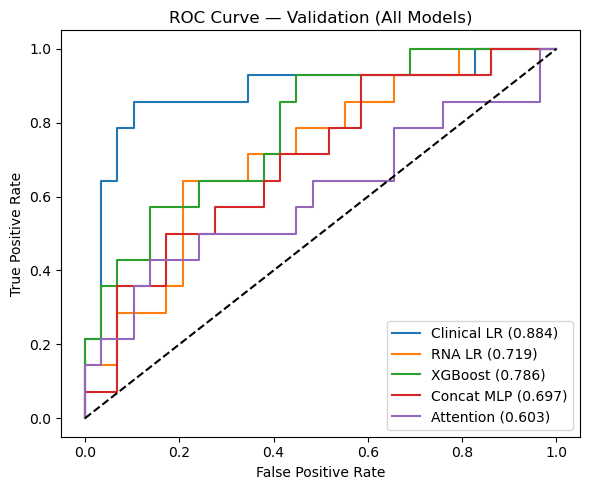

,n,events,event_rate,model
tier,,,,
high,9,5,0.555556,Concat MLP
mid,25,8,0.320000,Concat MLP
low,9,1,0.111111,Concat MLP


,n,events,event_rate,model
tier,,,,
high,9,5,0.555556,Attention
mid,25,7,0.280000,Attention
low,9,2,0.222222,Attention


In [13]:
# generate val predictions and compare all models
concat_model.eval()
attn_model.eval()
with torch.no_grad():
    y_val_pred_concat = concat_model(rna_val, clin_val).detach().cpu().numpy()
    y_val_pred_attn   = attn_model(rna_val, clin_val).detach().cpu().numpy()

baseline_val_df = pd.read_parquet("../models/baselines/predictions_val.parquet")
xgb_val_df      = pd.read_parquet("../models/xgboost/predictions_val.parquet")

models = [
    ("Clinical LR", baseline_val_df["y_pred_clin"].values),
    ("RNA LR",      baseline_val_df["y_pred_rna"].values),
    ("XGBoost",     xgb_val_df["y_pred_xgb"].values),
    ("Concat MLP",  y_val_pred_concat),
    ("Attention",   y_val_pred_attn),
]

# full ablation metrics table
metrics_df = pd.DataFrame([
    {"model": name, "val_roc_auc": roc_auc_score(y_val, preds), "val_ap": average_precision_score(y_val, preds)}
    for name, preds in models
])
display(metrics_df)

# ROC curves
fig, ax = plt.subplots(figsize=(6, 5))
for name, preds in models:
    fpr, tpr, _ = roc_curve(y_val, preds)
    auc = roc_auc_score(y_val, preds)
    ax.plot(fpr, tpr, label=f"{name} ({auc:.3f})")
ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Validation (All Models)")
ax.legend()
plt.tight_layout()
plt.show()

# risk-tier separation for deep learning models
def risk_tier_summary(y_true, y_pred, model_name):
    thresholds = np.percentile(y_pred, [80, 20])
    tiers = np.where(y_pred >= thresholds[0], "high",
             np.where(y_pred <= thresholds[1], "low", "mid"))
    return (
        pd.DataFrame({"y": y_true.values, "tier": tiers})
        .groupby("tier")["y"]
        .agg(n="count", events="sum", event_rate="mean")
        .reindex(["high", "mid", "low"])
        .assign(model=model_name)
    )

for name, preds in [("Concat MLP", y_val_pred_concat), ("Attention", y_val_pred_attn)]:
    display(risk_tier_summary(y_val, preds, name))

## 6. Evaluate final models on the test set
   - Generate test predictions for both deep learning models.
   - Compute final evaluation metrics and ROC curves.

,model,test_roc_auc,test_ap
0,Clinical LR,0.785714,0.675042
1,RNA LR,0.614286,0.473811
2,XGBoost,0.671429,0.474580
3,Concat MLP,0.685714,0.484247
4,Attention,0.550000,0.435852


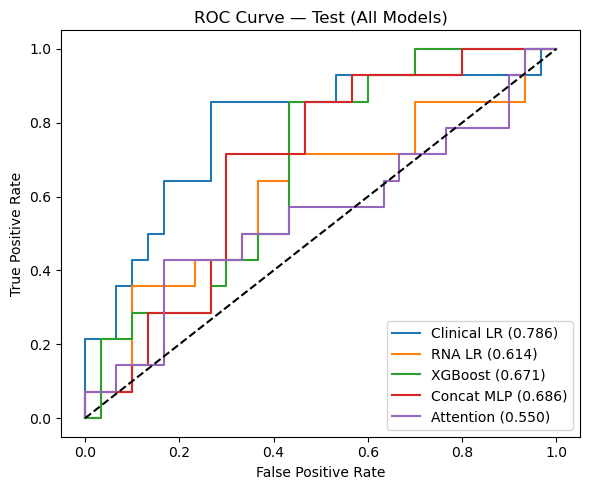

In [14]:
# evaluate both deep learning models on the test set
rna_test, clin_test, _ = to_tensors(X_rna_test_df, X_clin_test_df, y_test)

concat_model.eval()
attn_model.eval()
with torch.no_grad():
    y_test_pred_concat = concat_model(rna_test, clin_test).detach().cpu().numpy()
    y_test_pred_attn   = attn_model(rna_test, clin_test).detach().cpu().numpy()

baseline_test_df = pd.read_parquet("../models/baselines/predictions_test.parquet")
xgb_test_df      = pd.read_parquet("../models/xgboost/predictions_test.parquet")

test_models = [
    ("Clinical LR", baseline_test_df["y_pred_clin"].values),
    ("RNA LR",      baseline_test_df["y_pred_rna"].values),
    ("XGBoost",     xgb_test_df["y_pred_xgb"].values),
    ("Concat MLP",  y_test_pred_concat),
    ("Attention",   y_test_pred_attn),
]

test_metrics_df = pd.DataFrame([
    {"model": name, "test_roc_auc": roc_auc_score(y_test, preds), "test_ap": average_precision_score(y_test, preds)}
    for name, preds in test_models
])
display(test_metrics_df)

# ROC curves
fig, ax = plt.subplots(figsize=(6, 5))
for name, preds in test_models:
    fpr, tpr, _ = roc_curve(y_test, preds)
    auc = roc_auc_score(y_test, preds)
    ax.plot(fpr, tpr, label=f"{name} ({auc:.3f})")
ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Test (All Models)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Validate modeling outputs
   - Confirm prediction counts match split sizes.
   - Verify sample alignment across datasets.
   - Verify no data leakage between splits.

In [15]:
# confirm prediction counts match split sizes
assert len(y_val_pred_concat)  == len(y_val),  "concat val size mismatch"
assert len(y_val_pred_attn)    == len(y_val),  "attn val size mismatch"
assert len(y_test_pred_concat) == len(y_test), "concat test size mismatch"
assert len(y_test_pred_attn)   == len(y_test), "attn test size mismatch"

# verify no sample overlap between splits
assert len(set(X_rna_train_df.index) & set(X_rna_val_df.index))  == 0, "train/val overlap"
assert len(set(X_rna_train_df.index) & set(X_rna_test_df.index)) == 0, "train/test overlap"
assert len(set(X_rna_val_df.index)   & set(X_rna_test_df.index)) == 0, "val/test overlap"

print("All validation checks passed.")

All validation checks passed.


## 8. Test multimodal module

In [16]:
# Multimodal module smoke test

# run train_multimodal module via CLI
result = subprocess.run(
    [
        sys.executable,
        "../scripts/train_multimodal.py",
        "--assembled-dir", "../data/processed/assembled",
        "--outdir",        "../models/multimodal",
        "--n-epochs",      "10",
        "--random-state",  "42",
    ],
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(f"train_multimodal.py failed with exit code {result.returncode}")

# load artifacts
outdir_mod = Path("../models/multimodal")

with open(outdir_mod / "concat_model.pkl", "rb") as f:
    concat_loaded = pickle.load(f)
with open(outdir_mod / "attn_model.pkl", "rb") as f:
    attn_loaded = pickle.load(f)

preds_val_df  = pd.read_parquet(outdir_mod / "predictions_val.parquet")
preds_test_df = pd.read_parquet(outdir_mod / "predictions_test.parquet")
meta = json.loads((outdir_mod / "train_multimodal_metadata.json").read_text())

# prediction shape checks
assert len(preds_val_df)  == len(y_val),  "val prediction count mismatch"
assert len(preds_test_df) == len(y_test), "test prediction count mismatch"

# expected columns present
assert {"sample", "y_true", "y_pred_concat", "y_pred_attn"}.issubset(preds_val_df.columns)

# predictions are valid probabilities
assert preds_val_df["y_pred_concat"].between(0, 1).all(),  "concat val probs out of range"
assert preds_val_df["y_pred_attn"].between(0, 1).all(),    "attn val probs out of range"
assert preds_test_df["y_pred_concat"].between(0, 1).all(), "concat test probs out of range"
assert preds_test_df["y_pred_attn"].between(0, 1).all(),   "attn test probs out of range"

# metadata records correct feature counts
assert meta["dataset_statistics"]["n_clin_features"] == X_clin_train_df.shape[1], "clin feature count mismatch"
assert meta["dataset_statistics"]["n_rna_features"]  == X_rna_train_df.shape[1],  "rna feature count mismatch"
assert meta["dataset_statistics"]["n_samples_train"] == len(y_train), "train sample count mismatch"
assert meta["key_parameters_used"]["n_epochs"]       == 10,           "epoch count mismatch"

# loaded models have expected architecture
assert hasattr(concat_loaded, "head"), "concat model missing head"
assert hasattr(attn_loaded,   "attention"), "attn model missing attention layer"

print("train_multimodal module test passed.")
display(preds_val_df.head())


train: n=203, n_events=66, clin=98 features, rna=25431 features
val: n=43, n_events=14, clin=98 features, rna=25431 features
test: n=44, n_events=14, clin=98 features, rna=25431 features

--- Concatenation fusion model ---
Epoch  10 — train loss: 2.3223  val loss: 0.9198

--- Attention fusion model ---
Epoch  10 — train loss: 0.8879  val loss: 0.6196

--- Validation ---
Concat MLP  — ROC-AUC: 0.594  AP: 0.549
Attention   — ROC-AUC: 0.645  AP: 0.513

--- Test ---
Concat MLP  — ROC-AUC: 0.679  AP: 0.541
Attention   — ROC-AUC: 0.538  AP: 0.380

Artifacts saved to ../models/multimodal

train_multimodal module test passed.


,sample,y_true,y_pred_concat,y_pred_attn
0,TCGA-BH-A0DD-01A,0,0.205660,0.048406
1,TCGA-A2-A0D3-01A,0,0.244434,0.230337
2,TCGA-OL-A5D6-01A,1,0.091543,0.276219
3,TCGA-A2-A0CO-01A,1,0.007535,0.147573
4,TCGA-A8-A09X-01A,1,0.057754,0.219100
